In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## With torch, we can create and process tensors

In [3]:
# Create a number
tensor1 = torch.tensor(4.)
tensor1

tensor(4.)

In [4]:
tensor1.dtype # get the type of tensor

torch.float32

In [5]:
# Create a vector
tensor2 = torch.tensor([2., 3., 6., 9.])
tensor2

tensor([2., 3., 6., 9.])

In [6]:
tensor2.dtype

torch.float32

In [7]:
tensor3 = torch.tensor([2., 9., 3.], dtype=torch.float64)
tensor3

tensor([2., 9., 3.], dtype=torch.float64)

In [8]:
tensor3.dtype

torch.float64

In [9]:
# Create a matrix
tensor3 = torch.tensor([[1., 3], [4., 11.], [6., 5.]])

In [10]:
tensor3.shape

torch.Size([3, 2])

In [11]:
# Create a higher dimension tensor
tensor4 = torch.tensor([
    [
        [1., 2.],
        [4., 1.]
    ],
    [
        [2., 3.],
        [1., 22.]
    ],
    [
        [4., 5],
        [1., 55.]
    ]
])

In [12]:
tensor4.shape

torch.Size([3, 2, 2])

In [13]:
tensor5 = torch.tensor([[[2., 3., 4.], [1., -6., 4.], [2., 4., 6.]], [[6., 3., 3.], [6., -3., 7.], [1., 2., 3.]]])

In [14]:
tensor5.shape

torch.Size([2, 3, 3])

## Tensor Operations and Gradients

In [15]:
t1 = torch.tensor([1., 2., 3.])
t2 = torch.tensor([5., 3., 4.])
# Compute the dot the product
torch.dot(t1, t2)

tensor(23.)

In [16]:
# Multiply vectors element wise
torch.multiply(t1, t2)

tensor([ 5.,  6., 12.])

In [17]:
x = torch.tensor(5.)
w = torch.tensor(2., requires_grad=True)
b = torch.tensor(1., requires_grad=True)

x, w, b

(tensor(5.), tensor(2., requires_grad=True), tensor(1., requires_grad=True))

In [18]:
y = w * torch.pow(x, 2) + b

In [21]:
# Calculates the gradients on w and b
y.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [22]:
print(w.grad) # dy/dw

tensor(25.)


In [23]:
print(b.grad)

tensor(3.)


### Convert from numpy to torch tensor

In [24]:
np_arr = np.array(([1, 2, 3], [5, 6, 1]))

In [25]:
np_arr.shape

(2, 3)

In [26]:
type(np_arr)

numpy.ndarray

In [27]:
torch_tensor = torch.from_numpy(np_arr)

In [28]:
type(torch_tensor)

torch.Tensor

In [29]:
torch_tensor.dtype

torch.int32

## Linear Regression

In [30]:
import pandas as pd

In [31]:
df = pd.read_csv("./data/production.csv")
df

,region,temp,rainfall,humidity,apples,oranges
0,Kanto,73,67,43,56,70
1,Johto,91,88,64,81,101
2,Hoenn,87,134,58,119,133
3,Sinnoh,102,43,37,22,37
4,Unova,69,96,70,103,119


In [32]:
df.shape

(5, 6)

In [33]:
df = df.drop("region", axis=1)

In [34]:
df_data_features = df[["temp", "rainfall", "humidity"]]

In [35]:
df_data_target = df[["apples", "oranges"]]

In [36]:
data_features = df_data_features.to_numpy()
data_targets = df_data_target.to_numpy()

In [37]:
data_features

array([[ 73,  67,  43],
       [ 91,  88,  64],
       [ 87, 134,  58],
       [102,  43,  37],
       [ 69,  96,  70]], dtype=int64)

In [38]:
data_targets

array([[ 56,  70],
       [ 81, 101],
       [119, 133],
       [ 22,  37],
       [103, 119]], dtype=int64)

In [39]:
input_features = torch.from_numpy(data_features).float()
targets = torch.from_numpy(data_targets).float()

In [40]:
input_features

tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])

In [41]:
type(input_features), type(targets)

(torch.Tensor, torch.Tensor)

In [42]:
input_features.shape, targets.shape

(torch.Size([5, 3]), torch.Size([5, 2]))

In [43]:
w = torch.randn(2, 3, requires_grad=True)
b = torch.randn(2, requires_grad=True)

In [44]:
def model(x: torch.tensor) -> torch.tensor:
    return x @ w.T + b

In [45]:
def loss_function(t1: torch.tensor, t2: torch.tensor) -> torch.tensor: # mse
    diff = t1 - t2
    return torch.sum((diff * diff) / diff.numel())


In [46]:
def train(w, b, epochs: int=1000, alpha: float=1e-5) -> list:
    losses = []
    for idx in range(epochs):
        preds = model(input_features)
        loss = loss_function(preds, targets)
        losses.append(loss.detach())
        if idx % 5 == 0:
            print(f"The loss is {loss}")
        loss.backward()
        with torch.no_grad():
            w -= w.grad * alpha
            b -= b.grad * alpha
            w.grad.zero_()
            b.grad.zero_()
    return losses

In [47]:
losses = train(w, b)

The loss is 44451.35546875
The loss is 6247.88818359375
The loss is 937.4073486328125
The loss is 198.21641540527344
The loss is 94.35566711425781
The loss is 78.83064270019531
The loss is 75.62118530273438
The loss is 74.16047668457031
The loss is 72.97798156738281
The loss is 71.8673324584961
The loss is 70.798095703125
The loss is 69.76445007324219
The loss is 68.7638931274414
The loss is 67.79458618164062
The loss is 66.85497283935547
The loss is 65.9434585571289
The loss is 65.05844116210938
The loss is 64.19879913330078
The loss is 63.363128662109375
The loss is 62.55024337768555
The loss is 61.759010314941406
The loss is 60.98828887939453
The loss is 60.237159729003906
The loss is 59.50460433959961
The loss is 58.789859771728516
The loss is 58.09199142456055
The loss is 57.4102668762207
The loss is 56.743858337402344
The loss is 56.092079162597656
The loss is 55.45439529418945
The loss is 54.830074310302734
The loss is 54.21856689453125
The loss is 53.619300842285156
The loss is

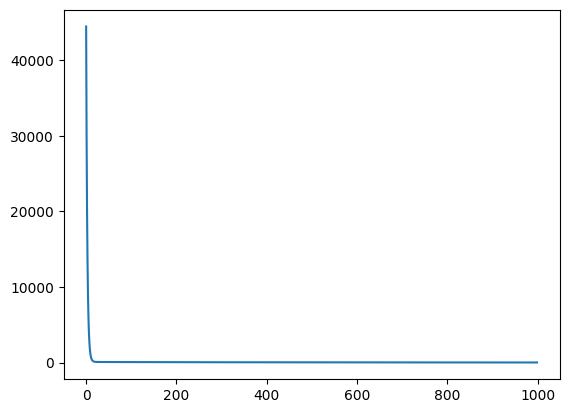

In [50]:
plt.plot(losses)

In [51]:
preds = model(input_features)
loss = loss_function(preds, targets)
print(loss)

tensor(11.2074, grad_fn=<SumBackward0>)


In [52]:
# Compare the preds and groundtruth
preds, targets

(tensor([[ 57.3570,  70.7259],
         [ 80.5657,  97.7940],
         [122.1173, 138.8313],
         [ 22.0273,  38.6399],
         [ 98.5114, 113.2835]], grad_fn=<AddBackward0>),
 tensor([[ 56.,  70.],
         [ 81., 101.],
         [119., 133.],
         [ 22.,  37.],
         [103., 119.]]))

## Use GPU

In [53]:
# check: nvidia-smi
! nvidia-smi

Mon Jun 24 22:47:20 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 546.01                 Driver Version: 546.01       CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 2060      WDDM  | 00000000:01:00.0 Off |                  N/A |
| N/A   41C    P5              13W /  30W |      0MiB /  6144MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [54]:


# Check if GPU is available

torch.cuda.is_available()

True

In [55]:
torch.cuda.device_count()

1

In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [57]:
device

device(type='cuda')

In [58]:
data = torch.tensor([1., 2., 3.])
data

tensor([1., 2., 3.])

In [59]:
data = data.to(device)

In [60]:
data

tensor([1., 2., 3.], device='cuda:0')